In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples, 
    davies_bouldin_score, 
    calinski_harabasz_score,
)

from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
datasets_files = [
    'S07-hw-dataset-01.csv',
    'S07-hw-dataset-02.csv',
    'S07-hw-dataset-03.csv'
]


def analyze_dataset(file_name):
    print(f"\n{'='*30}")
    print(f"АНАЛИЗ ФАЙЛА: {file_name}")
    print(f"{'='*30}")

    df = pd.read_csv(os.path.join("data", file_name))

    if 'sample_id' in df.columns:
        sample_ids = df['sample_id']
        X = df.drop(columns=['sample_id'])
    else:
        sample_ids = None
        X = df
        print("Предупреждение: столбец sample_id не найден.")

    print("\n--- Первые 5 строк (head) ---")
    display(X.head())
    
    print("\n--- Общая информация (info) ---")
    X.info()
    
    print("\n--- Проверка пропусков ---")
    null_counts = X.isnull().sum()
    null_percent = (null_counts / len(X)) * 100
    missing_data = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percent %'])
    print(missing_data[missing_data['Total'] > 0] if null_counts.sum() > 0 else "Пропусков нет")
    
    print("\n--- Описательная статистика ---")
    display(X.describe())
    
    num_features = X.select_dtypes(include=['number']).columns.tolist()
    cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"\nЧисловые признаки ({len(num_features)}): {num_features}")
    print(f"Категориальные признаки ({len(cat_features)}): {cat_features}")
    
    return X, sample_ids

data_storage = {}

for file in datasets_files:
    X_processed, ids = analyze_dataset(file)
    data_storage[file] = {'X': X_processed, 'ids': ids}


АНАЛИЗ ФАЙЛА: S07-hw-dataset-01.csv

--- Первые 5 строк (head) ---


,f01,f02,f03,f04,f05,f06,f07,f08
0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



--- Общая информация (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f01     12000 non-null  float64
 1   f02     12000 non-null  float64
 2   f03     12000 non-null  float64
 3   f04     12000 non-null  float64
 4   f05     12000 non-null  float64
 5   f06     12000 non-null  float64
 6   f07     12000 non-null  float64
 7   f08     12000 non-null  float64
dtypes: float64(8)
memory usage: 750.1 KB

--- Проверка пропусков ---
Пропусков нет

--- Описательная статистика ---


,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



Числовые признаки (8): ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Категориальные признаки (0): []

АНАЛИЗ ФАЙЛА: S07-hw-dataset-02.csv

--- Первые 5 строк (head) ---


...


Числовые признаки (3): ['x1', 'x2', 'z_noise']
Категориальные признаки (0): []

АНАЛИЗ ФАЙЛА: S07-hw-dataset-03.csv

--- Первые 5 строк (head) ---


,x1,x2,f_corr,f_noise
0,-2.710470,4.997107,-1.015703,0.718508
1,8.730238,-8.787416,3.953063,-1.105349
2,-1.079600,-2.558708,0.976628,-3.605776
3,6.854042,1.560181,1.760614,-1.230946
4,9.963812,-8.869921,2.966583,0.915899



--- Общая информация (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   x1       15000 non-null  float64
 1   x2       15000 non-null  float64
 2   f_corr   15000 non-null  float64
 3   f_noise  15000 non-null  float64
dtypes: float64(4)
memory usage: 468.9 KB

--- Проверка пропусков ---
Пропусков нет

--- Описательная статистика ---


,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.246296,1.033764,0.212776,-0.027067
std,4.592421,4.710791,1.530017,2.506375
min,-9.995585,-9.980853,-5.212038,-8.785884
25%,-1.782144,-2.666393,-0.966224,-1.731128
50%,0.664226,1.831257,0.296508,-0.052391
75%,4.435671,4.969630,1.390273,1.673831
max,16.207863,14.271153,5.795876,11.266865



Числовые признаки (4): ['x1', 'x2', 'f_corr', 'f_noise']
Категориальные признаки (0): []


In [3]:
def get_preprocessing_pipeline(X):
    """
    Создает Pipeline на основе типов признаков в X.
    """
    num_features = X.select_dtypes(include=['number']).columns.tolist()
    cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features)
        ],
        remainder='drop'
    )
    
    return preprocessor

processed_data = {}

for file_name, data in data_storage.items():
    X = data['X']
    
    preprocessor = get_preprocessing_pipeline(X)
    X_transformed = preprocessor.fit_transform(X)
    
    try:
        new_cols = preprocessor.get_feature_names_out()
    except:
        new_cols = [f"feat_{i}" for i in range(X_transformed.shape[1])]
    
    processed_data[file_name] = {
        'X_final': X_transformed,
        'feature_names': new_cols,
        'sample_ids': data['ids']
    }
    
    print(f"Препроцессинг {file_name} завершен. Итоговая размерность: {X_transformed.shape}")

Препроцессинг S07-hw-dataset-01.csv завершен. Итоговая размерность: (12000, 8)
Препроцессинг S07-hw-dataset-02.csv завершен. Итоговая размерность: (8000, 3)
Препроцессинг S07-hw-dataset-03.csv завершен. Итоговая размерность: (15000, 4)


In [4]:
def evaluate_kmeans(X, k_range=range(2, 11)):
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
    
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, scores, marker='o', linestyle='--')
    plt.title('KMeans: Silhouette Score vs k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()
    
    best_k = k_range[scores.index(max(scores))]
    print(f"Оптимальное k по силуэту: {best_k} (Score: {max(scores):.3f})")
    return best_k

def run_dbscan(X, eps_values=[0.3, 0.5, 0.7], min_samples=5):
    print(f"{'eps':<10} | {'n_clusters':<12} | {'noise_pct':<10} | {'silhouette'}")
    print("-" * 50)
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100
        
        if n_clusters > 1:
            mask = labels != -1
            score = silhouette_score(X[mask], labels[mask])
            print(f"{eps:<10} | {n_clusters:<12} | {noise_pct:<10.1f}% | {score:.3f}")
        else:
            print(f"{eps:<10} | {n_clusters:<12} | {noise_pct:<10.1f}% | N/A")

def run_agglomerative(X, k, linkages=['ward', 'complete']):
    for link in linkages:
        agg = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = agg.fit_predict(X)
        score = silhouette_score(X, labels)
        print(f"Agglomerative (linkage={link}, k={k}): Silhouette = {score:.3f}")

Dataset 01: Поиск оптимального k...


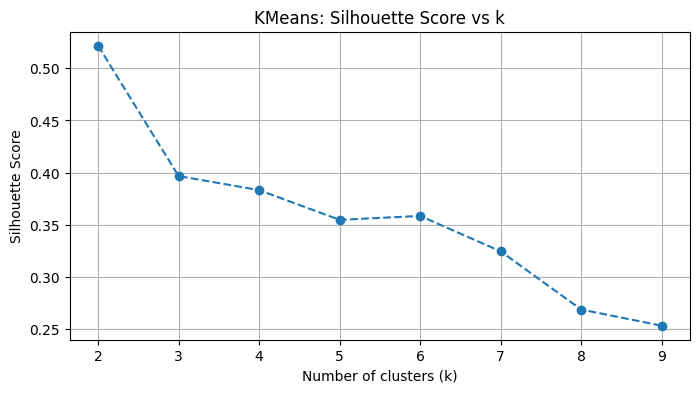

Оптимальное k по силуэту: 2 (Score: 0.522)

Сравнение с Agglomerative Clustering:
Agglomerative (linkage=ward, k=2): Silhouette = 0.522
Agglomerative (linkage=complete, k=2): Silhouette = 0.522


In [5]:
X1 = processed_data['S07-hw-dataset-01.csv']['X_final']

print("Dataset 01: Поиск оптимального k...")
best_k1 = evaluate_kmeans(X1, k_range=range(2, 10))

print("\nСравнение с Agglomerative Clustering:")
run_agglomerative(X1, k=best_k1, linkages=['ward', 'complete'])

Dataset 02: Результаты KMeans...


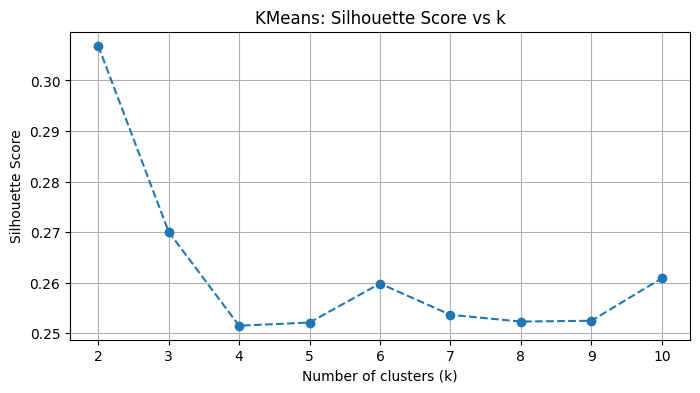

Оптимальное k по силуэту: 2 (Score: 0.307)

Dataset 02: Подбор параметров DBSCAN...
eps        | n_clusters   | noise_pct  | silhouette
--------------------------------------------------
0.2        | 9            | 10.2      % | -0.036
0.3        | 5            | 7.2       % | 0.085
0.5        | 14           | 4.5       % | -0.058
0.8        | 1            | 0.5       % | N/A


In [6]:
X2 = processed_data['S07-hw-dataset-02.csv']['X_final']

print("Dataset 02: Результаты KMeans...")
best_k2 = evaluate_kmeans(X2)

print("\nDataset 02: Подбор параметров DBSCAN...")
run_dbscan(X2, eps_values=[0.2, 0.3, 0.5, 0.8], min_samples=5)

Dataset 03: Анализ KMeans...


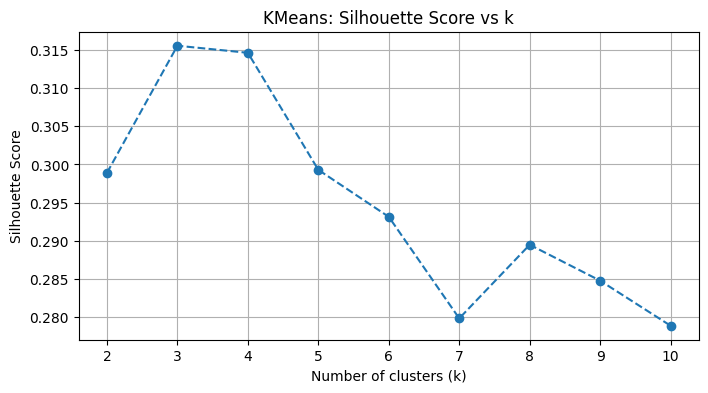

Оптимальное k по силуэту: 3 (Score: 0.316)

Dataset 03: Альтернативные методы...
eps        | n_clusters   | noise_pct  | silhouette
--------------------------------------------------
0.4        | 4            | 7.5       % | 0.120
0.6        | 1            | 1.8       % | N/A
1.0        | 1            | 0.1       % | N/A
Agglomerative (linkage=ward, k=3): Silhouette = 0.309
Agglomerative (linkage=average, k=3): Silhouette = 0.256


In [7]:
X3 = processed_data['S07-hw-dataset-03.csv']['X_final']

print("Dataset 03: Анализ KMeans...")
best_k3 = evaluate_kmeans(X3)

print("\nDataset 03: Альтернативные методы...")
run_dbscan(X3, eps_values=[0.4, 0.6, 1.0], min_samples=10)
run_agglomerative(X3, k=best_k3, linkages=['ward', 'average'])

In [8]:
def calculate_clustering_metrics(X, labels, model_name):
    """
    Рассчитывает метрики, учитывая специфику шума в DBSCAN.
    """
    n_total = len(labels)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / n_total
    
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]
    
    n_clusters = len(set(labels_filtered))
    
    metrics = {
        "Model": model_name,
        "Noise %": round(noise_ratio * 100, 2),
        "Clusters": n_clusters
    }
    
    if n_clusters > 1 and len(X_filtered) > n_clusters:
        metrics.update({
            "Silhouette": round(silhouette_score(X_filtered, labels_filtered), 4),
            "Davies-Bouldin": round(davies_bouldin_score(X_filtered, labels_filtered), 4),
            "Calinski-Harabasz": round(calinski_harabasz_score(X_filtered, labels_filtered), 2)
        })
    else:
        metrics.update({
            "Silhouette": None,
            "Davies-Bouldin": None,
            "Calinski-Harabasz": None
        })
        print(f"Предупреждение для {model_name}: недостаточно кластеров для расчёта метрик.")
        
    return metrics

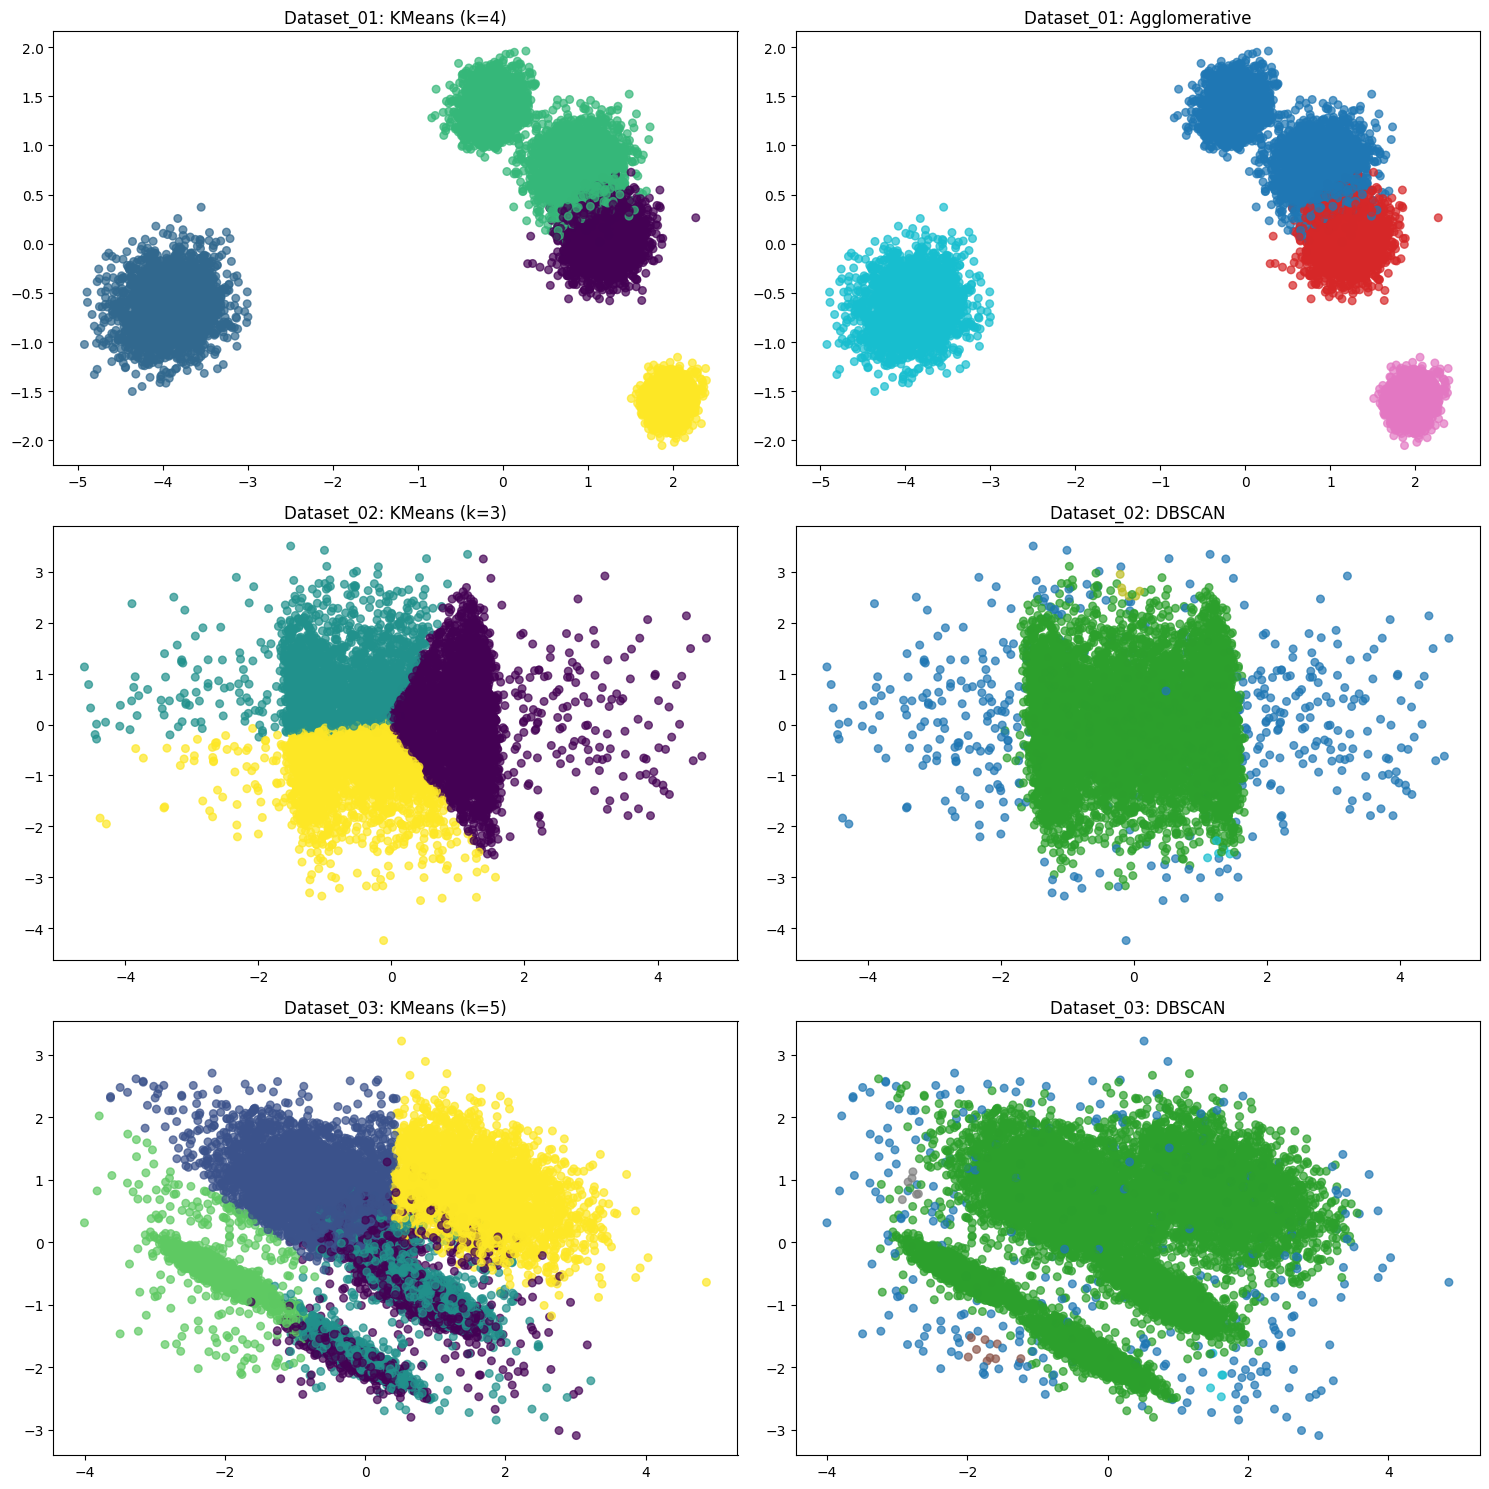

,Model,Noise %,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,Dataset_01_KMeans,0.00,4,0.3833,1.1603,9427.50
1,Dataset_01_Agglomerative,0.00,4,0.3832,1.1603,9425.77
2,Dataset_02_KMeans,0.00,3,0.2700,1.2227,3082.27
3,Dataset_02_DBSCAN,7.24,5,0.0852,0.5897,21.95
4,Dataset_03_KMeans,0.00,5,0.2993,1.1686,6125.13
5,Dataset_03_DBSCAN,2.22,4,-0.1044,0.8424,12.76


In [9]:
def process_and_visualize(datasets_dict):
    final_report = []
    fig, axes = plt.subplots(len(datasets_dict), 2, figsize=(15, 5 * len(datasets_dict)))
    
    for idx, (name, data) in enumerate(datasets_dict.items()):
        X = data['X_final']
        
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        km = KMeans(n_clusters=data['k'], n_init=10, random_state=42)
        km_labels = km.fit_predict(X)
        
        if 'dbscan_eps' in data:
            model = DBSCAN(eps=data['dbscan_eps'], min_samples=5)
            alt_name = "DBSCAN"
        else:
            model = AgglomerativeClustering(n_clusters=data['k'], linkage='ward')
            alt_name = "Agglomerative"
            
        alt_labels = model.fit_predict(X)
        
        final_report.append(calculate_clustering_metrics(X, km_labels, f"{name}_KMeans"))
        final_report.append(calculate_clustering_metrics(X, alt_labels, f"{name}_{alt_name}"))
        
        axes[idx, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', s=30, alpha=0.7)
        axes[idx, 0].set_title(f"{name}: KMeans (k={data['k']})")
        

        scatter = axes[idx, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=alt_labels, cmap='tab10', s=30, alpha=0.7)
        axes[idx, 1].set_title(f"{name}: {alt_name}")
        
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(final_report)

configs = {
    'Dataset_01': {'X_final': X1, 'k': 4}, 
    'Dataset_02': {'X_final': X2, 'k': 3, 'dbscan_eps': 0.3},
    'Dataset_03': {'X_final': X3, 'k': 5, 'dbscan_eps': 0.5} 
}

report_df = process_and_visualize(configs)
display(report_df)


--- Визуализация для S07-hw-dataset-01.csv ---


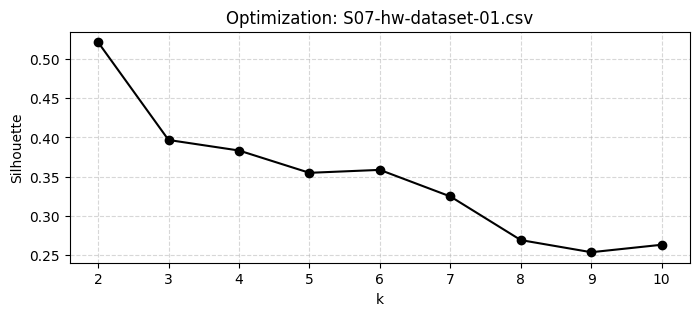

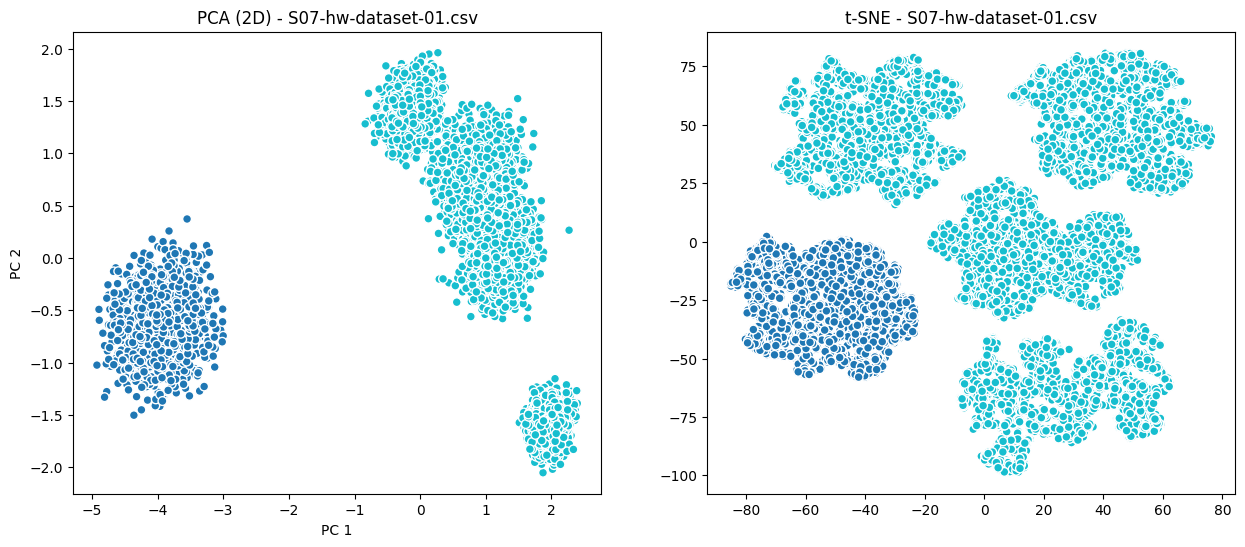


--- Визуализация для S07-hw-dataset-02.csv ---


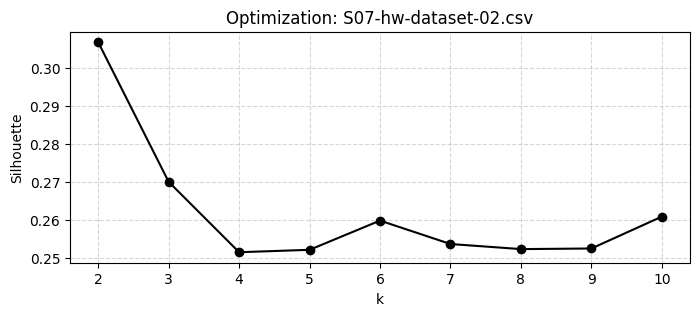

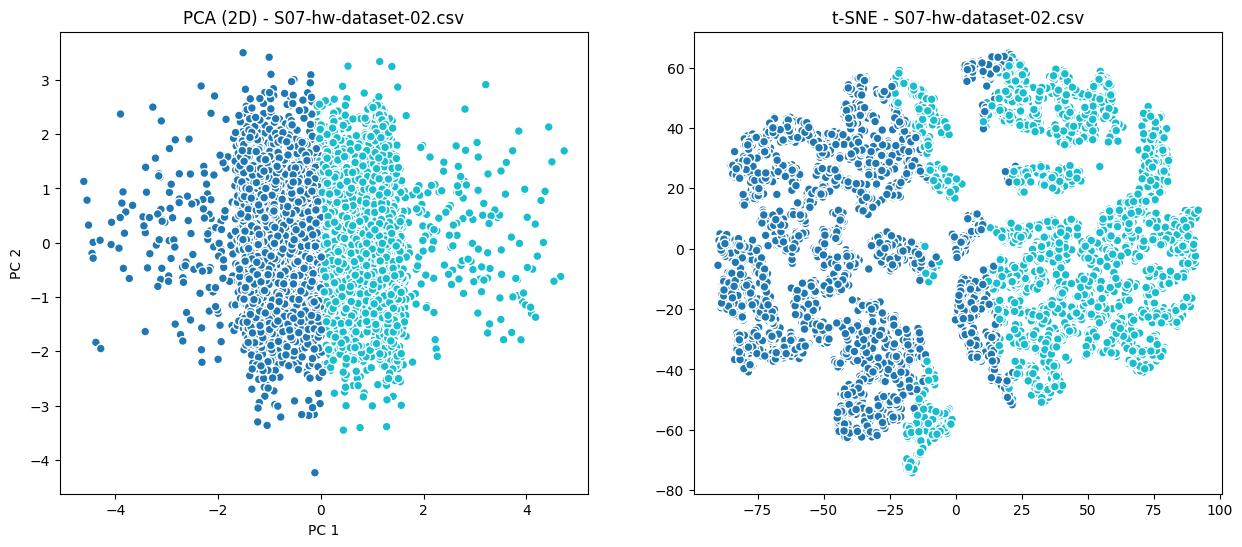


--- Визуализация для S07-hw-dataset-03.csv ---


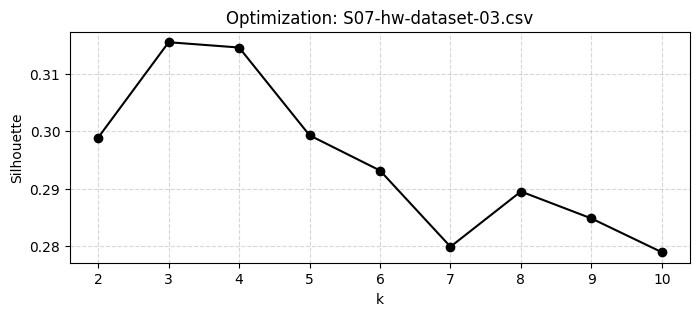

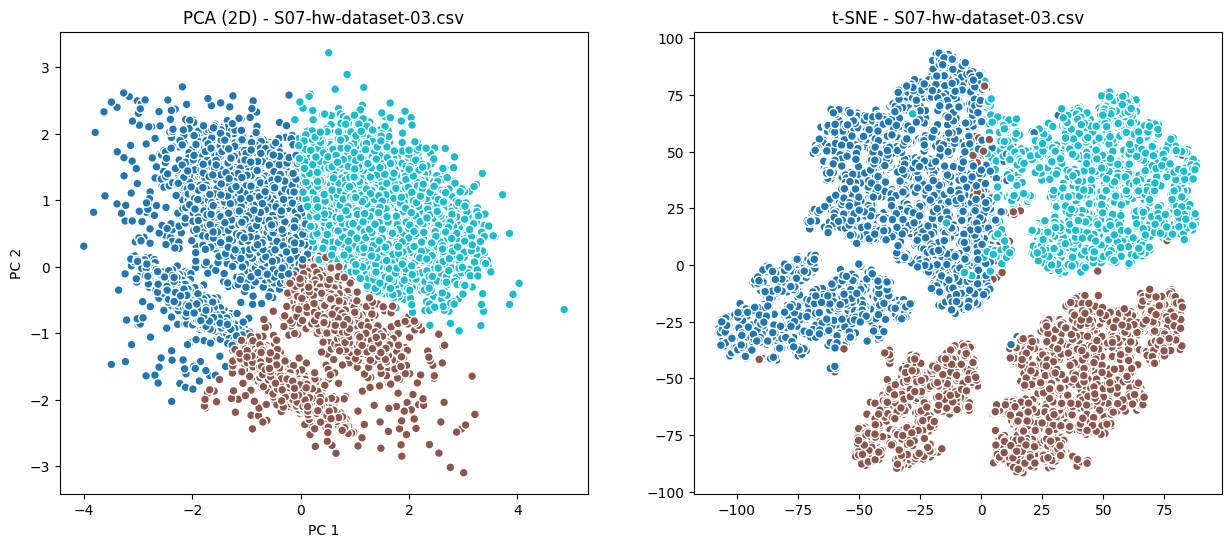

In [10]:
datasets_to_plot = ['S07-hw-dataset-01.csv', 'S07-hw-dataset-02.csv', 'S07-hw-dataset-03.csv']

for file_name in datasets_to_plot:
    X_scaled = processed_data[file_name]['X_final']
    
    print(f"\n--- Визуализация для {file_name} ---")
    
    k_range = range(2, 11)
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels_tmp = km.fit_predict(X_scaled)
        scores.append(silhouette_score(X_scaled, labels_tmp))

    plt.figure(figsize=(8, 3))
    plt.plot(k_range, scores, marker='o', color='black')
    plt.title(f"Optimization: {file_name}")
    plt.xlabel("k")
    plt.ylabel("Silhouette")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    best_k = k_range[np.argmax(scores)]
    best_model = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    labels_best = best_model.fit_predict(X_scaled)

    pca_res = PCA(n_components=2).fit_transform(X_scaled)
    
    tsne_res = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    scatter1 = ax1.scatter(pca_res[:, 0], pca_res[:, 1], c=labels_best, cmap='tab10', edgecolors='w', s=40)
    ax1.set_title(f"PCA (2D) - {file_name}")
    ax1.set_xlabel("PC 1")
    ax1.set_ylabel("PC 2")
    
    scatter2 = ax2.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels_best, cmap='tab10', edgecolors='w', s=40)
    ax2.set_title(f"t-SNE - {file_name}")
    
    plt.show()

In [11]:
X_stable = processed_data['S07-hw-dataset-01.csv']['X_final']

best_k = 3 
random_states = [1, 42, 100, 2023, 777]
results = []

print(f"Запуск проверки устойчивости для {best_k} кластеров...")

for rs in random_states:
    km = KMeans(n_clusters=best_k, n_init=1, random_state=rs)
    labels = km.fit_predict(X_stable)
    results.append(labels)

ari_scores = []
for i in range(len(results)):
    for j in range(i + 1, len(results)):
        score = adjusted_rand_score(results[i], results[j])
        ari_scores.append(score)

mean_ari = np.mean(ari_scores)
min_ari = np.min(ari_scores)

print("-" * 30)
print(f"Результаты проверки (ARI):")
print(f"Средняя похожесть: {mean_ari:.4f}")
print(f"Минимальная похожесть: {min_ari:.4f}")
print("-" * 30)

if mean_ari > 0.9:
    print("Вывод: Алгоритм демонстрирует высокую устойчивость. Разбиения почти идентичны при разных random_state.")
else:
    print("Вывод: Алгоритм умеренно устойчив. Начальная инициализация влияет на итоговые границы кластеров.")

Запуск проверки устойчивости для 3 кластеров...
------------------------------
Результаты проверки (ARI):
Средняя похожесть: 0.7024
Минимальная похожесть: 0.5041
------------------------------
Вывод: Алгоритм умеренно устойчив. Начальная инициализация влияет на итоговые границы кластеров.


In [12]:
base_path = 'artifacts/'
folders = ['labels', 'figures']
for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

metrics_summary = {}
best_configs = {}

datasets_list = ['S07-hw-dataset-01.csv', 'S07-hw-dataset-02.csv', 'S07-hw-dataset-03.csv']

for i, ds_name in enumerate(datasets_list, 1):
    X_scaled = processed_data[ds_name]['X_final']
    sample_ids = processed_data[ds_name]['sample_ids']
    metrics_summary[ds_name] = {}
    
    k_range = range(2, 11)
    k_scores = []
    for k in k_range:
        km_temp = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
        k_scores.append(silhouette_score(X_scaled, km_temp.labels_))
    
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, k_scores, marker='o', color='black')
    plt.title(f"Optimization: Silhouette vs K ({ds_name})")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(f"{base_path}figures/opt_ds{i}.png")
    plt.close()

    best_k = k_range[np.argmax(k_scores)]
    km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_scaled)
    

    eps_val = 0.5 if "01" in ds_name else 0.3
    db = DBSCAN(eps=eps_val, min_samples=5).fit(X_scaled)

    def collect_results(X, labels, name):
        mask = labels != -1
        if len(np.unique(labels[mask])) < 2:
            return None
        res = {
            "silhouette": float(silhouette_score(X[mask], labels[mask])),
            "davies_bouldin": float(davies_bouldin_score(X[mask], labels[mask])),
            "calinski_harabasz": float(calinski_harabasz_score(X[mask], labels[mask])),
            "noise_pct": float(np.mean(labels == -1) * 100) if -1 in labels else 0.0
        }
        return res

    km_res = collect_results(X_scaled, km.labels_, "KMeans")
    db_res = collect_results(X_scaled, db.labels_, "DBSCAN")
    
    if km_res: metrics_summary[ds_name]["KMeans"] = km_res
    if db_res: metrics_summary[ds_name]["DBSCAN"] = db_res


    if db_res and db_res['silhouette'] > km_res['silhouette']:
        best_labels = db.labels_
        best_model_name = "DBSCAN"
        params = {"eps": eps_val, "min_samples": 5}
    else:
        best_labels = km.labels_
        best_model_name = "KMeans"
        params = {"n_clusters": int(best_k)}

    best_configs[ds_name] = {
        "best_model": best_model_name,
        "params": params,
        "criterion": "Highest Silhouette Score on non-noise points"
    }

    labels_df = pd.DataFrame({'sample_id': sample_ids, 'cluster_label': best_labels})
    labels_df.to_csv(f"{base_path}labels/labels_hw07_ds{i}.csv", index=False)

    pca_res = PCA(n_components=2).fit_transform(X_scaled)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(pca_res[:, 0], pca_res[:, 1], c=best_labels, cmap='tab10', edgecolors='white', s=40)
    plt.title(f"Best Solution PCA: {ds_name} ({best_model_name})")
    plt.colorbar(scatter)
    plt.savefig(f"{base_path}figures/pca_ds{i}.png")
    plt.close()

with open(f"{base_path}metrics_summary.json", 'w') as f:
    json.dump(metrics_summary, f, indent=4)

with open(f"{base_path}best_configs.json", 'w') as f:
    json.dump(best_configs, f, indent=4)

print("Все артефакты (6 графиков, 3 CSV и 2 JSON) успешно сохранены в папку artifacts/")

Все артефакты (6 графиков, 3 CSV и 2 JSON) успешно сохранены в папку artifacts/
